### Practice Exericse (Decision Tree Regression Model)

In [21]:
from pathlib import Path
import sys

current_dir = Path.cwd()
project_root = current_dir.parent.absolute()

sys.path.insert(0,str(project_root))

from config import DT2_FEATURE_IMPORTANCES

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [23]:
df = pd.read_csv(DT2_FEATURE_IMPORTANCES)

print(f'Shape of the Dataset: {df.shape}')
print(f'Missing Values in dataset:\n {df.isnull().sum()}')
print(f'Dataset:\n{df.head()}')

Shape of the Dataset: (10, 4)
Missing Values in dataset:
 Size_SqFt      0
Age_Years      0
Bedrooms       0
Price_Lakhs    0
dtype: int64
Dataset:
   Size_SqFt  Age_Years  Bedrooms  Price_Lakhs
0       1000         10         2           35
1       1500          5         3           55
2       1200          8         2           40
3       1800          3         3           70
4       2000          1         4           85


In [24]:
#feature and targett variable
X = df[['Size_SqFt','Age_Years','Bedrooms']]
y = df['Price_Lakhs']




In [25]:
#training the model

from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(
    max_depth=2,
    random_state = 42
)

dt.fit(X,y)

DecisionTreeRegressor(max_depth=2, random_state=42)

In [26]:
# Extracting the feature_importances_
features = X.columns

imp_feat = dt.feature_importances_

df_feat = pd.DataFrame({
    'Features': features,
    'Importances Features' : imp_feat
})
df_feat

,Features,Importances Features
0,Size_SqFt,0.930277
1,Age_Years,0.000000
2,Bedrooms,0.069723


C:\Users\parde\AppData\Local\Temp\ipykernel_14780\2154186389.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


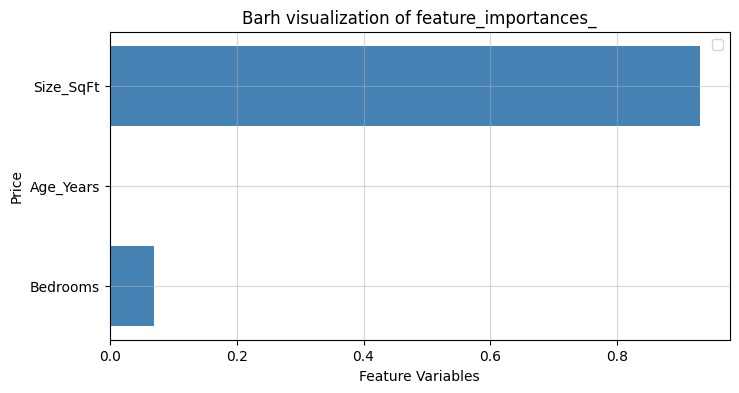

In [30]:
#visualization 
plt.figure(figsize=(8,4))
plt.barh(df_feat['Features'],df_feat['Importances Features'],color='steelblue')
plt.ylabel('Price')
plt.xlabel('Feature Variables')
plt.title('Barh visualization of feature_importances_')
plt.grid(True,alpha=0.5)
plt.legend()
plt.gca().invert_yaxis()
plt.show()